In [4]:
from autoslo.blueprint_selection.query_timeline import QueryTimeline
from autoslo.blueprints.cluster import Cluster
from autoslo.workload_execution.trace import Trace
from autoslo.models.iconq_model import IconqModel

run_id = '1763278486'
iconq_model_id = '1767983798'

trace  = Trace(run_id=run_id)
model = IconqModel.load(model_id=iconq_model_id)

timeline = QueryTimeline(model._iconq_query_featurizer, model._iconq_interaction_featurizer)
timeline.initialize_from_trace(trace, model.stage_model)

Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1767983798/model_1767985867.pth


In [5]:
timeline._interval_trees

defaultdict(intervaltree.intervaltree.IntervalTree,
            {'cluster_16': IntervalTree([Interval(1763278486.650039, 1763278487.191643, {'query_id': 'cluster_16_11783886#d902ffa9-d1d7-4c9a-bf30-c2e1d467e8d4', 'tpcds_temp_and_q_idx': '019_003', 'featurization': [6.0, 25.12117276355514, 5.0, 17.701459900591274, 2.0, 17.61858988029538, 0.0, 0.0, 1.0, 9.67595940353184, 1.0, 21.23075439128468, 1.0, 9.67595940353184, 1.0, 9.67595940353184, 0.0, 0.0, 1.0, 9.67595940353184, 1.0, 8.682707631588727, 0.0, 0.0, 2.0, 17.704842456452802, 0.0, 0.0, 0.0, 0.0, 25.119101997281625, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 18.379858749432213, 18.09217667698047, 0.0, 11.750042924928678, 0.0, 4.787491826115376, 0.0, 0.0, 0.0, 0.0, 9.39465993226448, 0.0, 0.0], 'stage_model_predictions_per_rpu': {32: 6.9744053333333325, 64: 3.2122185230255127, 128: 3.2122185230255127, 256: 3.2122185230255127, 4: 174.72313999999997, 512: 3.2122185230255127, 8: 16.121851888888887, 16: 7.47579411111111}}), Interval(1763278560.873577, 1

In [8]:
trace.run_id

'1763278486'

In [12]:
from autoslo.blueprint_selection.selector import BlueprintSelector
from autoslo.workload_definition.chunk import Chunk
import autoslo.utils.paths as pu


workload = Chunk.load('tpcds_99templates_25pctheavy_60meaninterarrivals')

selector = BlueprintSelector(
    workload=workload,
    slo_s=20.0,
    slo_violation_rate_threshold=0.05,
    iconq_model_id = iconq_model_id,
    cluster_name = 'cluster_8',
    init_from_trace=True
)

Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1767983798/model_1767985867.pth
Initializing from trace with run ID: 1763282030


In [14]:
selector.solve()

SLO iteration 0: reduced SLO violation rate from 0.5714 to 0.4921 by applying move QueryMove(query_id='cluster_8_5487671#42599321-eca9-463b-b6bf-8cf65f696ef9', from_cluster_name='cluster_8', to_cluster_name='cluster_4').


In [7]:
selector._query_timeline._interval_trees

defaultdict(intervaltree.intervaltree.IntervalTree,
            {'cluster_8': IntervalTree([Interval(0.0, 0.5188578367233276, {'query_id': 0, 'tpcds_temp_and_q_idx': '019_003', 'featurization': [6.0, 25.12117276355514, 5.0, 17.701459900591274, 2.0, 17.61858988029538, 0.0, 0.0, 1.0, 9.67595940353184, 1.0, 21.23075439128468, 1.0, 9.67595940353184, 1.0, 9.67595940353184, 0.0, 0.0, 1.0, 9.67595940353184, 1.0, 8.682707631588727, 0.0, 0.0, 2.0, 17.704842456452802, 0.0, 0.0, 0.0, 0.0, 25.119101997281625, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 18.379858749432213, 18.09217667698047, 0.0, 11.750042924928678, 0.0, 4.787491826115376, 0.0, 0.0, 0.0, 0.0, 9.39465993226448, 0.0, 0.0], 'stage_model_predictions_per_rpu': {32: 6.9744053333333325, 64: 3.2122185230255127, 128: 3.2122185230255127, 256: 3.2122185230255127, 4: 174.72313999999997, 512: 3.2122185230255127, 8: 16.121851888888887, 16: 7.47579411111111}}), Interval(74.2158250123447, 77.60507314505038, {'query_id': 1, 'tpcds_temp_and_q_idx': '090_003', 'fe

In [91]:
fig = render_gantt_scrubber(
    selector._recorder.snapshots,
    slo_s=selector._slo_s,
    constant_layout=True,
    violation_rate_threshold=0.05
)
fig.write_html("blueprint_selection_timeline.html", auto_play=False)

AttributeError: 'NoneType' object has no attribute 'get'

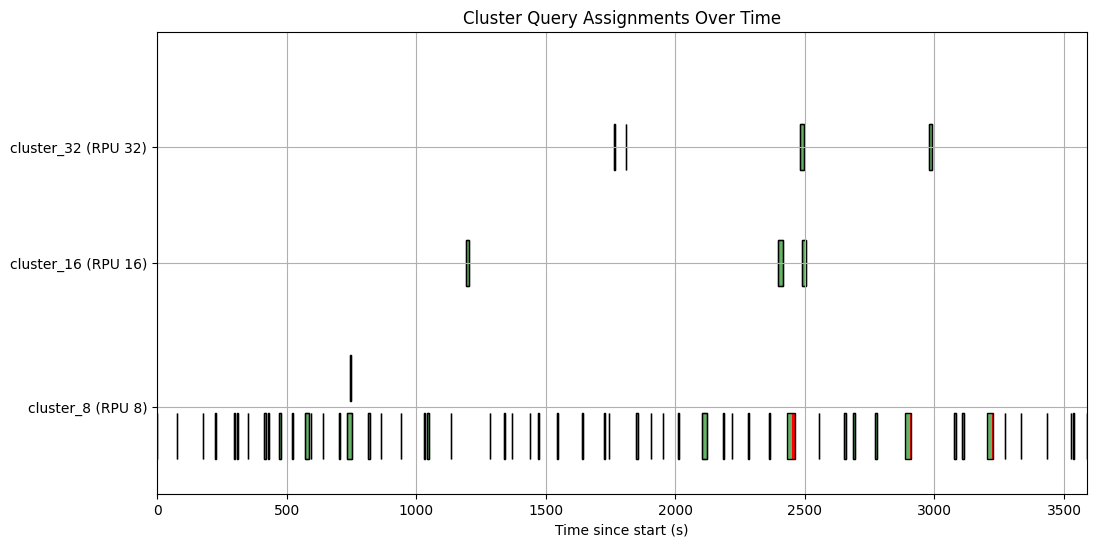

In [50]:
selector._query_timeline.draw_gantt_chart(
    slo_s=20.0)


In [51]:
selector._query_timeline.slo_violation_rate(slo_s=20.0)

0.047619047619047616

In [45]:
import pandas as pd
# Make sure that each interval is identically represented in the two data structures
rows = []
count_1 = 0
count_2 = 0
for query_id in selector._query_timeline.query_ids:
    count_1 += 1    
    cluster_name, interval = selector._query_timeline._query_id_to_cluster_interval[query_id]
    start_time = interval.begin
    end_time = interval.end
    row = {
        'query_id': query_id,
        'cluster_name_dict': cluster_name,
        'interval_tree_start_dict': start_time,
        'interval_tree_end_dict': end_time
    }
    rows.append(row)

rows_df = pd.DataFrame(rows)
rows_df['cluster_name_tree'] = None
rows_df['interval_tree_start_tree'] = None
rows_df['interval_tree_end_tree'] = None

for cluster_name, interval_tree in selector._query_timeline._interval_trees.items():
    for interval in interval_tree:
        count_2 += 1
        query_id = interval.data['query_id']
        rows_df.loc[rows_df['query_id'] == query_id, 'cluster_name_tree'] = cluster_name
        rows_df.loc[rows_df['query_id'] == query_id, 'interval_tree_start_tree'] = interval.begin
        rows_df.loc[rows_df['query_id'] == query_id, 'interval_tree_end_tree'] = interval.end



In [47]:
assert all(rows_df['cluster_name_dict'] == rows_df['cluster_name_tree'])
assert all(rows_df['interval_tree_start_dict'] == rows_df['interval_tree_start_tree'])
assert all(rows_df['interval_tree_end_dict'] == rows_df['interval_tree_end_tree'])